In [1]:
!pip install /Users/alexathorne/development/personal/creaturenv

Processing /Users/alexathorne/development/personal/creaturenv
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for creaturenv: filename=creaturenv-0.1.0-py3-none-any.whl size=20752 sha256=3b0b096648dcd331ac06ebf505f11e1a89e8e351a26a93ecbc1a836cc80aab81
  Stored in directory: /private/var/folders/pb/2v43qld56svb17jrw__wt5mm0000gn/T/pip-ephem-wheel-cache-di3ecqeo/wheels/10/0f/57/e9193dd3aaaefd623502b7eb0d9d346bc57b646270e0eeaaa4
Successfully built creaturenv
  Attempting uninstall: creaturenv
    Found existing installation: creaturenv 0.1.0
    Uninstalling creaturenv-0.1.0:
      Successfully uninstalled creaturenv-0.1.0

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
from reflect.components.flow_world_model.dynamic_model import DynamicFlowModel, DynamicAttentionalFlowModel
from reflect.components.flow_world_model.world_model_actor import WorldModelActor
from reflect.components.flow_world_model.world_model import WorldModel
from reflect.data.loader import EnvDataLoader
from reflect.components.models.actor import Actor
from reflect.components.trainers.value.value_trainer import ValueGradTrainer
from reflect.components.trainers.value.critic import ValueCritic

from tqdm import tqdm
from livelossplot import PlotLosses
import gymnasium as gym
from dataclasses import asdict
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torch.optim as optim
import numpy as np
import torch.nn as nn
from torch.distributions import Normal
import envs.chain_reacher


/Users/alexathorne/development/personal/world-model-rl/venv/lib/python3.10/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment InvertedPendulum-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(


In [3]:
env = gym.make(
    'ChainReacher-v0',
    render_mode='rgb_array',
    n_links=1,
    n_obs=0,
    link_length=1.0,
    obstacle_seed=8,
    max_torque=0.5,
    n_lidar_rays=0,
    lidar_range=4.0,
    max_episode_steps=1000,
    upright_target=True,
)

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]
device='cpu'


In [4]:
actor = Actor(
    input_dim=state_dim,
    output_dim=action_dim,
    bound=env.action_space.high,
).to(device)

critic = ValueCritic(
    state_dim=state_dim,
).to(device)

trainer = ValueGradTrainer(
    actor=actor,
    critic=critic,
    actor_lr=0.001,
    critic_lr=0.001,
)
trainer.to(device)

In [5]:

world_model_actor = WorldModelActor(
    actor=actor,
)

env_data_loader = EnvDataLoader(
    num_time_steps=3,
    rollout_length=200,
    num_runs=1000,
    noise_size=0.3,
    state_shape=(state_dim,),
    policy=world_model_actor,
    env=env,
    use_imgs_as_states=False,
)


In [6]:
for _ in tqdm(range(10)):
    env_data_loader.perform_rollout()

100%|██████████| 10/10 [00:03<00:00,  2.94it/s]


In [7]:
state_dim_model = state_dim+1+1
action_dim_model = action_dim

dynamic_model = DynamicFlowModel(
    input_dim=state_dim,
    conditioning_dim=3*(state_dim_model + action_dim_model),
    output_dim=state_dim_model,
    time_embed_dim=16,
    hidden_dim=128,
    depth=2,
    use_layer_norm=True,
    num_positions=3,
)

world_model = WorldModel(
    dynamic_model=dynamic_model,
    observation_dim=state_dim,
    action_dim=action_dim_model,
    environment_action_bound=env.action_space.high,
)

# dynamic_model = DynamicAttentionalFlowModel(
#     input_dim=state_dim_model,
#     conditioning_dim=state_dim_model + action_dim_model,
#     output_dim=state_dim_model,
#     num_heads=4,
#     hidden_dim=256,
#     depth=2,
#     use_layer_norm=True,
#     num_positions=3,
# )

# world_model = WorldModel(
#     dynamic_model=dynamic_model,
#     observation_dim=state_dim_model-2,
#     action_dim=action_dim,
#     environment_action_bound=env.action_space.high,
# )


In [8]:
plot_losses = PlotLosses(
  groups={
    'flow_loss': ['flow_loss'],
    'rel_err': ['rel_err'],
    'value_loss': ['value_loss'],
    'value_grad_norm': ['value_grad_norm'],
    'actor_loss': ['actor_loss'],
    'actor_grad_norm': ['actor_grad_norm'],
    'reward': ['reward'],
    'imagined_reward': ['imagined_reward'],
  },
)

In [9]:
def test_actor(actor, env, render=False):
    o, *_ = env.reset()
    total_reward = 0
    images = []
    for _ in range(1000):
        a = actor(torch.tensor(o), deterministic=True)
        o, r, d, *_ = env.step(a.detach())
        if render:
            images.append(env.render())
        total_reward += r
        if d:
            break
    if render:
        return total_reward, images
    else:
        return total_reward

test_actor(actor, env)


-592.8224612200509

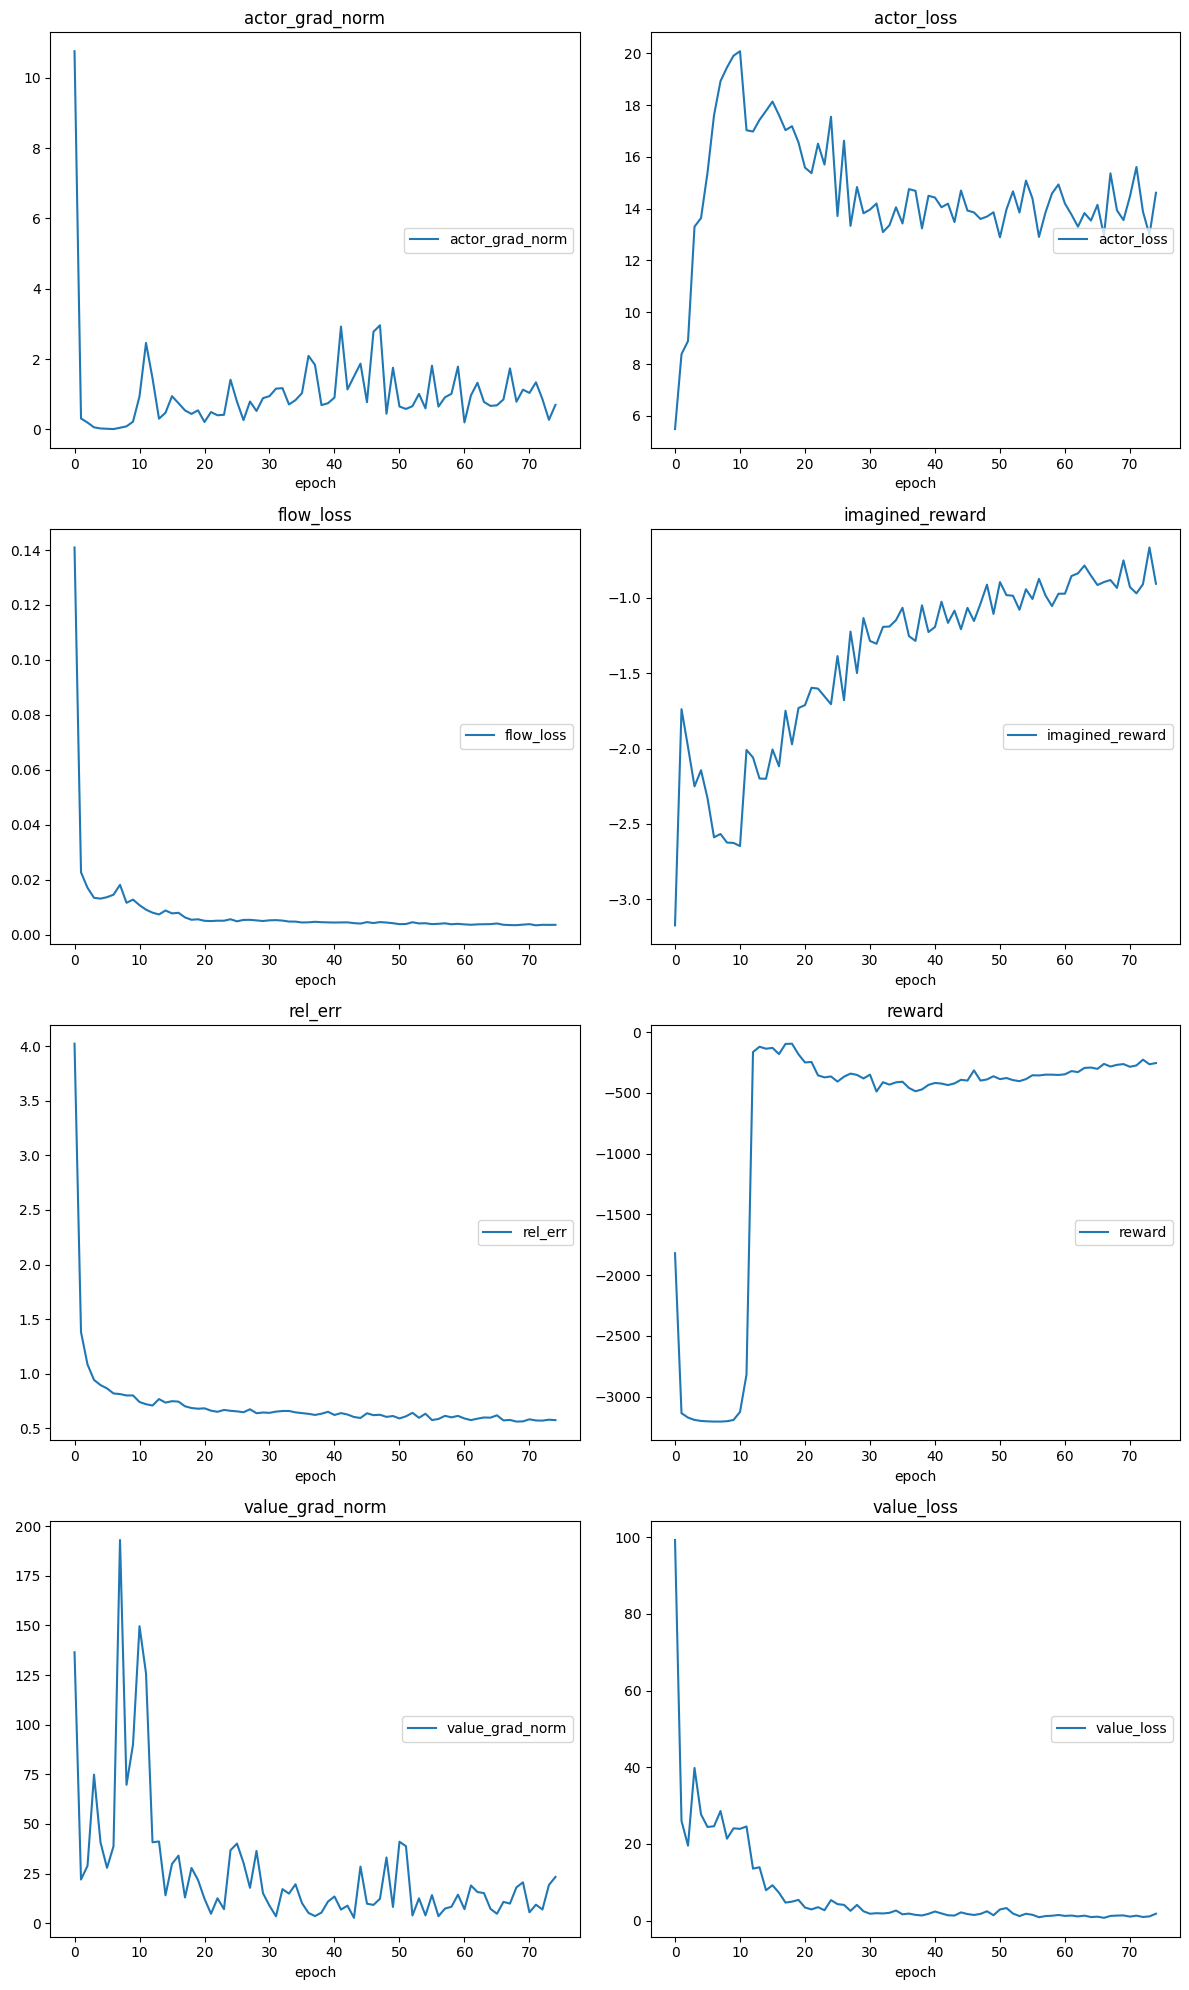

actor_grad_norm
	actor_grad_norm  	 (min:    0.005, max:   10.761, cur:    0.695)
actor_loss
	actor_loss       	 (min:    5.487, max:   20.080, cur:   14.615)
flow_loss
	flow_loss        	 (min:    0.003, max:    0.141, cur:    0.004)
imagined_reward
	imagined_reward  	 (min:   -3.173, max:   -0.666, cur:   -0.907)
rel_err
	rel_err          	 (min:    0.562, max:    4.022, cur:    0.576)
reward
	reward           	 (min: -3205.476, max:  -95.317, cur: -254.429)
value_grad_norm
	value_grad_norm  	 (min:    2.742, max:  192.981, cur:   23.344)
value_loss
	value_loss       	 (min:    0.751, max:   99.264, cur:    1.825)


In [10]:

update_every = 10

for epoch in range(750):
    env_data_loader.perform_rollout()
    _, _, o, a, r, d = env_data_loader.sample(
        batch_size=256,
        num_time_steps=4
    )
    world_model_losses = world_model.update(o, a, r, d)

    _, _, o, a, r, d = env_data_loader.sample(
        batch_size=256,
        num_time_steps=3
    )

    o.requires_grad = True
    a.requires_grad = True
    r.requires_grad = True
    d = d.to(torch.float32)
    d.requires_grad = True

    img_o, img_a, img_r, img_d = world_model.imagine_rollout(
        o, a, r, d,
        actor,
        num_timesteps=10,
        num_flow_steps=1,
        noise_scale=0.0
    )

    trainer_history = trainer.update(
        state_samples=img_o,
        reward_samples=img_r,
        done_samples=img_d
    )

    trainer_history = asdict(trainer_history)
    world_model_losses = asdict(world_model_losses)
    if epoch % update_every == 0:        
        plot_losses.update(
            {
                **world_model_losses,
                **trainer_history,
                'reward': test_actor(actor, env),
                'imagined_reward': img_r.detach().sum(-1).mean()
            }
        )
        plot_losses.send()
        total_loss = 0 
        total_rel_err = 0


/var/folders/pb/2v43qld56svb17jrw__wt5mm0000gn/T/ipykernel_85063/3168068086.py:22: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:278.)
  o = torch.tensor(obs)[None]


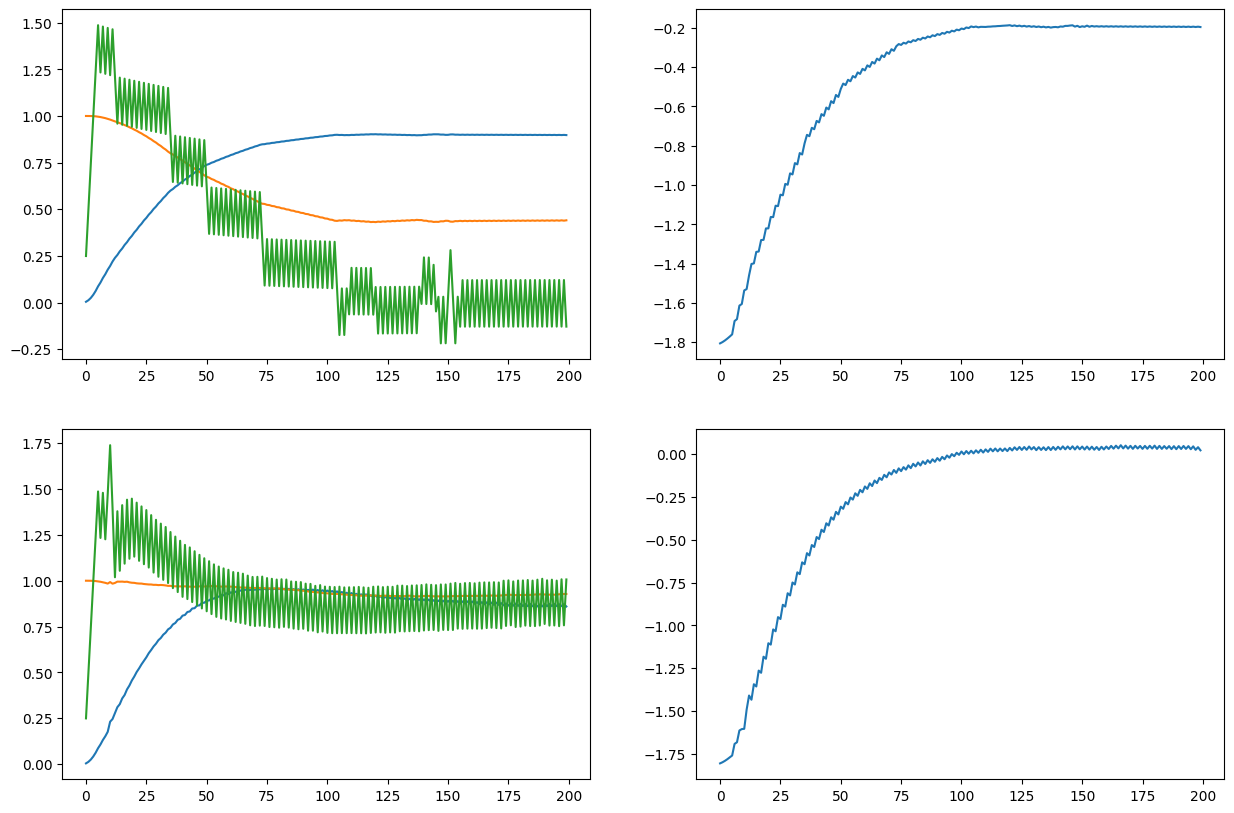

In [11]:
o, *_ = env.reset(seed=3)
total_reward = 0
images = []
obs = []
actions = []
rewards = []
dones = []

for _ in range(1000):
    a = actor(torch.tensor(o).to(torch.float32).to(device), deterministic=True)
    # a = env.action_space.sample()
    a = a.cpu().detach().numpy()
    o, r, d, t, info = env.step(a)
    obs.append(o)
    actions.append(a)
    rewards.append(r)
    dones.append(d)
    images.append(env.render())
    if d:
        break

o = torch.tensor(obs)[None]
a = torch.tensor(actions)[None]
r = torch.tensor(rewards)[None, :, None].to(torch.float32)
d = torch.tensor(dones)[None, :, None].to(torch.float32)

import matplotlib.pyplot as plt
import random

start_i=0
length=200

img_o, img_a, img_r, img_d = world_model.imagine_rollout(
    o[:, start_i:start_i+10],
    a[:, start_i:start_i+10],
    r[:, start_i:start_i+10],
    d[:, start_i:start_i+10],
    actor,
    num_timesteps=length,
    num_flow_steps=100,
    noise_scale=0.001
)

img_o = img_o.detach()
img_r = img_r.detach()
fig, axs = plt.subplots(ncols=2, nrows=2, figsize=(15, 10))
axs[0, 0].plot(o[0, start_i:length+start_i, 0].cpu())
axs[0, 0].plot(o[0, start_i:length+start_i, 1].cpu())
axs[0, 0].plot(o[0, start_i:length+start_i, 2].cpu())
axs[0, 1].plot(r[0, start_i:length+start_i, 0].cpu())

axs[1, 0].plot(img_o[0, :length, 0].cpu())
axs[1, 0].plot(img_o[0, :length, 1].cpu())
axs[1, 0].plot(img_o[0, :length, 2].cpu())
axs[1, 1].plot(img_r[0, :length, 0].cpu())

plt.show()

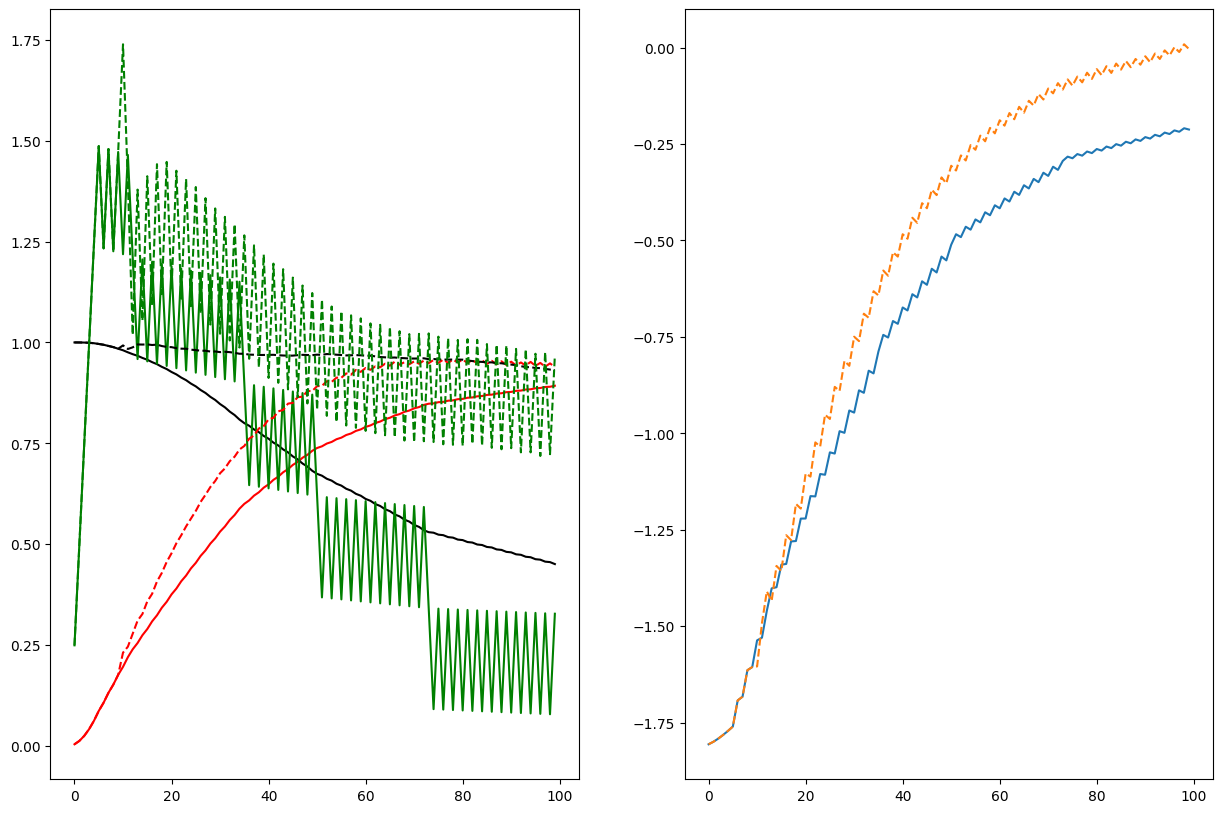

In [12]:
start_i=0
length=100

img_o = img_o.detach()
img_r = img_r.detach()
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(15, 10))
axs[0].plot(o[0, start_i:length+start_i, 0].cpu(), color='red', linestyle='-')
axs[0].plot(o[0, start_i:length+start_i, 1].cpu(), color='black', linestyle='-')
axs[0].plot(o[0, start_i:length+start_i, 2].cpu(), color='green', linestyle='-')
axs[1].plot(r[0, start_i:length+start_i, 0].cpu())

axs[0].plot(img_o[0, :length, 0].cpu(), color='red', linestyle='--',)
axs[0].plot(img_o[0, :length, 1].cpu(), color='black', linestyle='--',)
axs[0].plot(img_o[0, :length, 2].cpu(), color='green', linestyle='--',)
axs[1].plot(img_r[0, :length, 0].cpu(), linestyle='--',)

plt.show()

In [13]:
reward, images = test_actor(actor, env, render=True)
print(reward)

-248.63982095080328


In [14]:
from matplotlib import animation
from IPython.display import HTML
import matplotlib.pyplot as plt

# Create figure and axis
fig, ax = plt.subplots(figsize=(6, 6))
ax.axis('off')

# Display first frame
im = ax.imshow(images[0])

# Animation update function
def update(frame):
    im.set_array(images[frame])
    return [im]

# Create animation
anim = animation.FuncAnimation(
    fig, 
    update, 
    frames=len(images),
    interval=20,  # milliseconds between frames (50 FPS)
    blit=True
)

# Display in notebook
plt.close()  # Prevent static image from showing
HTML(anim.to_html5_video())

In [15]:
reward

-248.63982095080328

In [16]:
images = []
for i_o in img_o[0, :]:
    image = env.unwrapped.render_from_state(i_o.cpu().numpy())
    images.append(image)

fig, ax = plt.subplots(figsize=(6, 6))
ax.axis('off')

im = ax.imshow(images[0])

def update(frame):
    im.set_array(images[frame])
    return [im]

anim = animation.FuncAnimation(
    fig,
    update,
    frames=len(images),
    interval=20,
    blit=True
)

plt.close()
HTML(anim.to_html5_video())